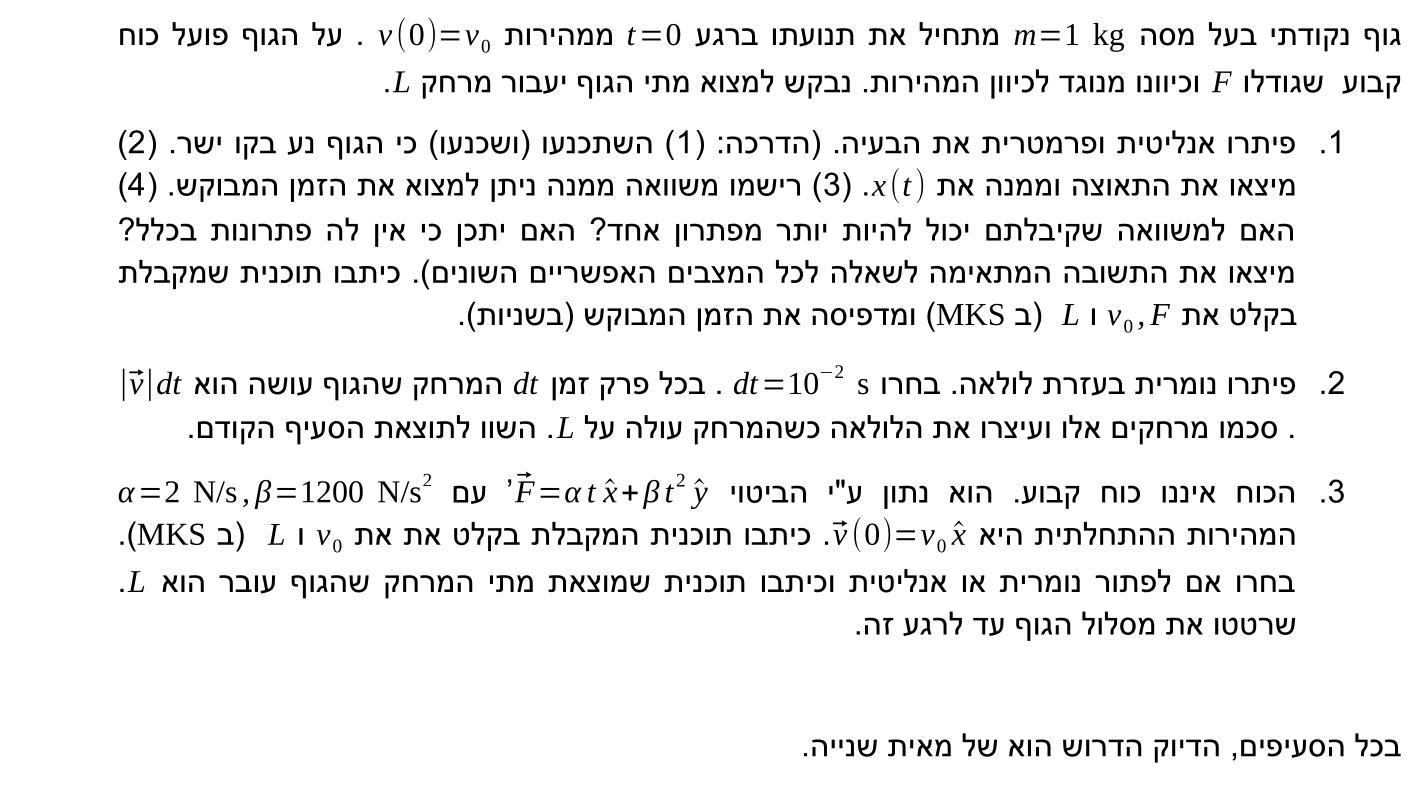

In [ ]:
import numpy as np
F=float(input())
v0=float(input())
L=float(input())
qn=int(input())
m=1

# === Q1: Analytical — find t when total path length = L ===
t_star = m * v0 / F          # time body stops (v=0)
x_max  = m * v0**2 / (2 * F) # max distance before reversal

if L <= x_max:
    # L reached before body stops — solve quadratic x(t)=L
    disc = v0**2 - 2 * F * L / m
    t_1  = (v0 - np.sqrt(disc)) / (F / m)
else:
    # L reached after reversal — time = stop time + freefall from rest
    t_1 = t_star + np.sqrt(2 * m * (L - x_max) / F)

# === Q2: Euler method — fixed force F in -x, track path length until S=L ===
dt  = 1e-2
v, S, t = v0, 0.0, 0.0
t_2 = float('nan')

while t < 1e4:
    v += (-F / m) * dt   # update velocity (force always in -x)
    t += dt
    S += abs(v) * dt     # accumulate path length
    if S >= L:
        t_2 = t
        break

# === Q3: Euler method — time-varying force F=(αt)x̂+(βt²)ŷ, track path until S=L ===
alpha, beta = 2, 1200
dt = 1e-2
vx, vy = v0, 0.0
S, t = 0.0, 0.0
t_3 = float('nan')

while t < 1e4:
    vx += (alpha * t / m) * dt       # x-acceleration: αt/m
    vy += (beta  * t**2 / m) * dt    # y-acceleration: βt²/m
    t  += dt
    S  += np.sqrt(vx**2 + vy**2) * dt  # arc length element |v|dt
    if S >= L:
        t_3 = t
        break

Answers=[0,t_1,t_2,t_3]
ans=Answers[qn]
print(f'{ans:.3g}')